# Butterfly Scale Spectral Analysis
------
## Problem Statement
Butterfly wings consist of many unique patterns and colours that are the result of a long history of selective evolutionary pressures. The cause of these patterns and colours is more complex than these wings simply absorbing and reflecting different wavelengths of light. Butterfly wings consists of multiple layers of scales, each of which consists of unique nano-scale (pun not intended) structures that cause the light incident on its surface to undergo diffraction, diffusion and other interference effects which results in unique interplay between various wavelengths of light that cause the colours and patterns seen on butterfly wings.

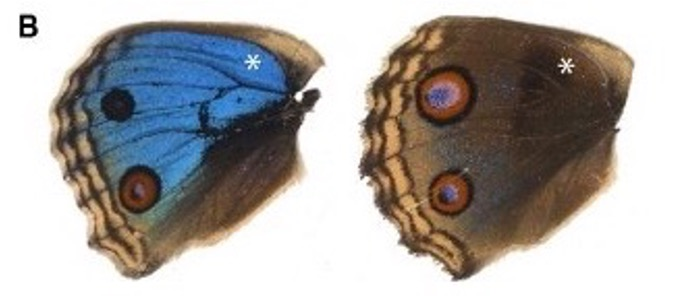

Since the colours of a butterfly’s wings are dependent on how the nanostructures of the butterfly’s scales manipulate light, an exact understanding of how these nanostructures do so requires information not just of its 3D structure, but also of the scale’s material’s densities and refractive indices. A basic start to understanding the material's densities and refractive indices, we would need a better understanding of the chemical composition found in the scales. We could do this with the aid of spectro-ptychography.

--------------
# Task 0: Import Necessary Packages

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# YOUR TURN: Include the other packages you intend to use
from skimage.morphology import remove_small_objects, erosion, disk



-------

# Task 1: Loading the data and some simple EDA
Firstly, when given a h5 file, it is usually a good idea to check its contents first. Run the code below to see the contents of ```bicyclus_wt_carbon.h5```.

In [2]:
# A function like this helps us list all the contents in a h5 file!
def display_h5_hierarchy(g, indent=0):
    """
    Recursively prints the hierarchy of an HDF5 group or file, including shape and dtype of datasets.
    """
    for key in g:
        item = g[key]
        if isinstance(item, h5py.Group):
            print('  ' * indent + f"- {key}/ [Group]")
            display_h5_hierarchy(item, indent + 1)
        elif isinstance(item, h5py.Dataset):
            print('  ' * indent + f"- {key} [Dataset] shape={item.shape}, dtype={item.dtype}")

In [5]:
with h5py.File("bicyclus_wt_c.h5", "r") as f:
    keys = display_h5_hierarchy(f)

- amplitude [Dataset] shape=(76, 350, 350), dtype=float32
- energy_ev [Dataset] shape=(76,), dtype=float32
- phase [Dataset] shape=(76, 350, 350), dtype=float32


We see from above the there are 3 arrays found in ```bicyclus_wt_carbon.h5```.

```energy_ev``` is an array of shape ```(76,)```. The values are in eV (electron volts) and each element of this array represents a value of X-ray energy at which a ptychographic scan was conducted.

```amplitude``` is an array of shape ```(76, 533, 533)```. It contains the amplitude values of each scan conducted at the 76 energy values. 

```phase``` is an array of shape ```(76, 533, 533)```. It contains the phase value of each scan conducted at the 76 energy values.

Next, we need to import over the (carbon) spectral data of the butterfly scale. Run the code below to import the data.

In [8]:
with h5py.File("bicyclus_wt_c.h5", "r") as f:
    phase_im = np.asarray(f["phase"]) # I have chosen to call this variable phase_im as it contains 'images' of the phases
    amplitude_im = np.asarray(f["amplitude"]) # Similar idea for amplitude_im
    energy = np.asarray(f["energy_ev"])

Let's explore this dataset! We should first check what energy values the scans were conducted for. Let print them out below

In [9]:
print(energy)

[278.  279.  280.  281.  282.  283.  283.2 283.4 283.6 283.8 284.  284.2
 284.4 284.6 284.8 285.  285.2 285.4 285.6 285.8 286.  286.2 286.4 286.6
 286.8 287.  287.2 287.4 287.6 287.8 288.  288.2 288.4 288.6 288.8 289.
 289.2 289.4 289.6 289.8 290.  290.2 290.4 290.6 290.8 291.  291.2 291.4
 291.6 291.8 292.  292.2 292.4 292.6 292.8 293.  293.2 293.4 293.6 293.8
 294.  295.  296.  297.  298.  299.  300.  301.  302.  303.  304.  305.
 306.  307.  308.  309. ]


Next, let understand the entries of ```amplitude_im``` and ```phase_im```. We can plot out the amplitudes and the phases for a given energy value using the code below.

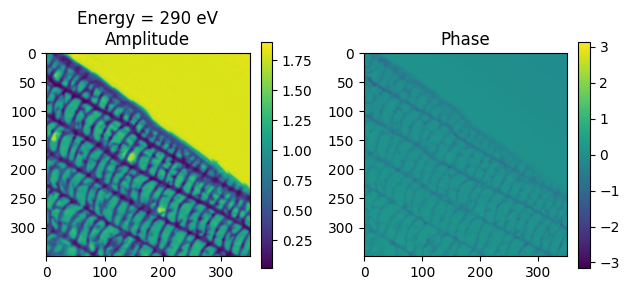

In [10]:
chosen_energy = 290  # YOUR TURN: Play around by adjusting this number to any other energy value found above.

###### DO NOT EDIT THIS PART ######
energy_ind = np.where(energy == chosen_energy)[0][0]
amplitude_to_show, phase_to_show = amplitude_im[energy_ind], phase_im[energy_ind]

fig, axes = plt.subplots(1, 2, dpi = 100)
amp = axes[0].imshow(amplitude_to_show)
axes[0].set_title(f'Energy = {chosen_energy} eV\nAmplitude')
plt.colorbar(mappable = amp, fraction = 0.05)

pha = axes[1].imshow(phase_to_show, vmin = -np.pi, vmax = np.pi)
axes[1].set_title('\nPhase')
plt.colorbar(mappable = pha, fraction = 0.05)

plt.tight_layout()
###### DO NOT EDIT THIS PART ######

Once you have understood that each entry along the 0-th axis for ```amplitude_im``` and ```phase_im``` correspond to an energy in ```energy```, we are now ready to see how the chemical spectra of each pixel can be obtained. Simply by aligning all reconstructed image together, we can plot out the pixel intensity for each energy to obtain a chemical spectra! Experiment with the code below to see it yourself.

**For now, we will only be focusing on the amplitudes.**

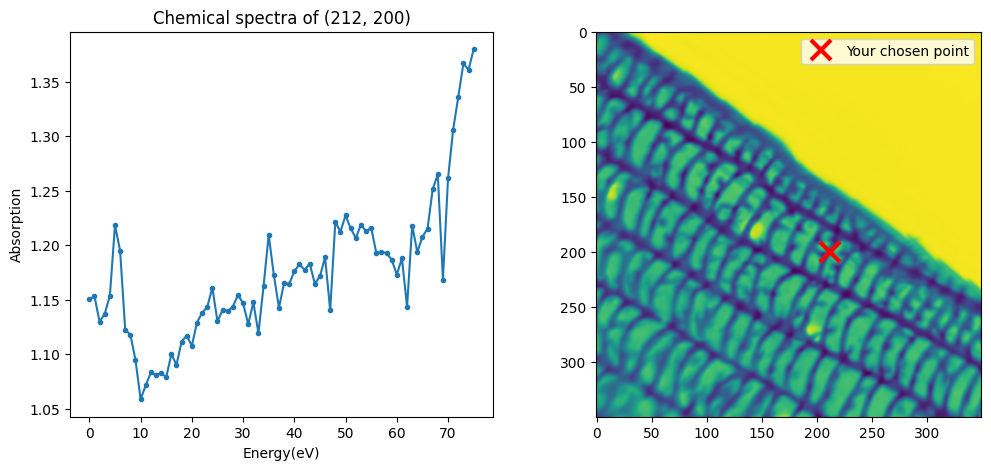

In [12]:
# ---- COORDINATE SYSTEM ----
# Increasing x: Rightwards
# Increasing y: Downwards

x_loc, y_loc = 212,200 # YOUR TURN: Adjust these values to explore the spectra

chosen_spectra = amplitude_im[:, x_loc, y_loc]

fig, axes = plt.subplots(1, 2, dpi = 100, figsize = (12, 5))
axes[0].plot(chosen_spectra, '.-')
axes[0].set_title(f'Chemical spectra of {(x_loc, y_loc)}')
axes[0].set_xlabel('Energy(eV)')
axes[0].set_ylabel('Absorption')


axes[1].imshow(amplitude_im.mean(axis = 0))
axes[1].plot(x_loc, y_loc, 'x', color = 'r', markersize = 15, markeredgewidth = 3, label = 'Your chosen point')
axes[1].legend()

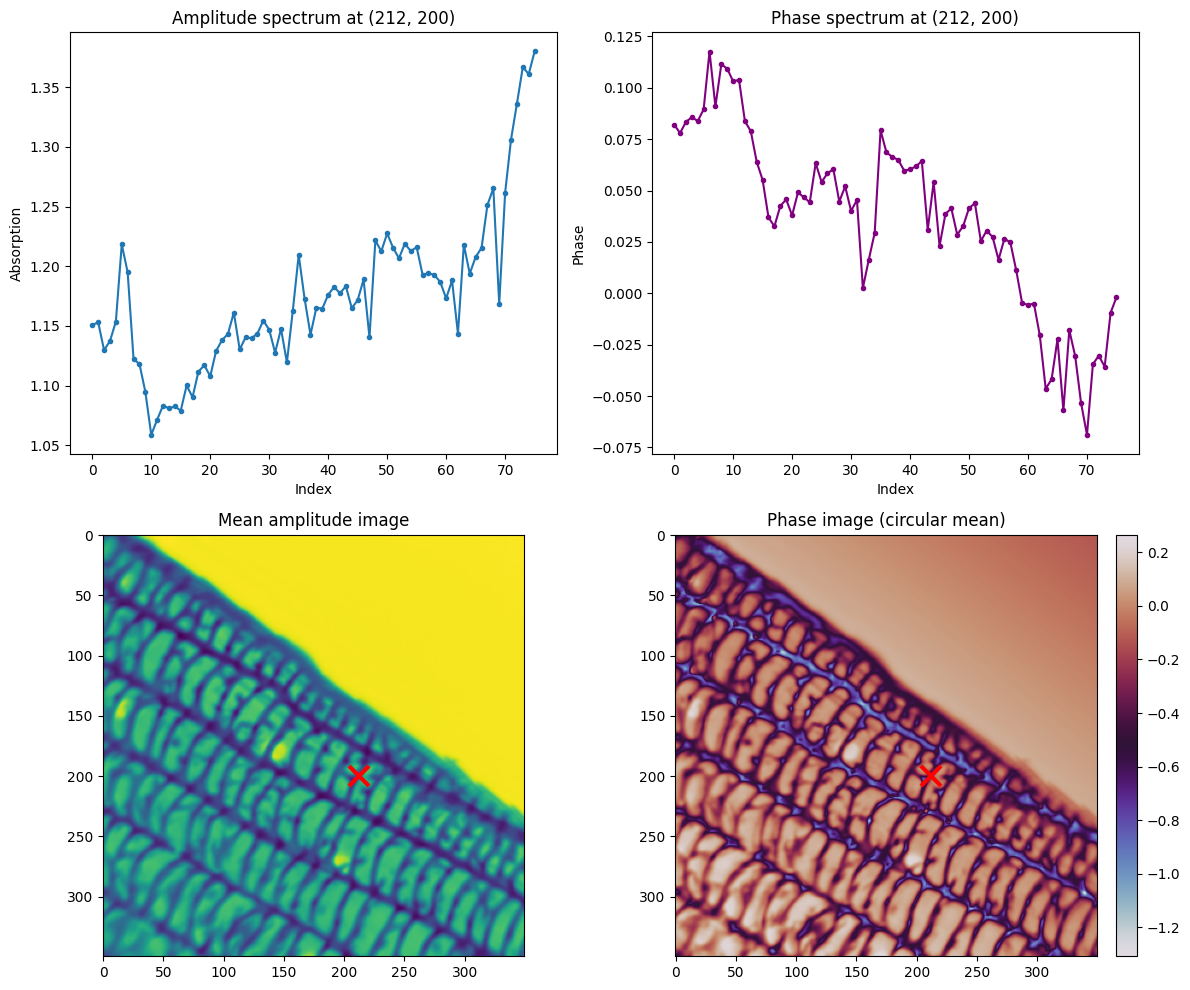

In [16]:
# ---- COORDINATE SYSTEM ----
# Increasing x: Rightwards
# Increasing y: Downwards

x_loc, y_loc = 212, 200  # YOUR TURN: Adjust these values to explore the spectra

chosen_amp = amplitude_im[:, x_loc, y_loc]
chosen_phase = phase_im[:, x_loc, y_loc]

# 如果你有 energy_ev，建议用它做横坐标；没有就用 index
x_axis = chosen_spectra if 'Energy(eV)' in globals() else np.arange(amplitude_im.shape[0])

# phase 图像建议不要直接普通平均，最好用 circular mean
phase_display = np.angle(np.mean(np.exp(1j * phase_im), axis=0))

fig, axes = plt.subplots(2, 2, dpi=100, figsize=(12, 10))

# amplitude spectrum
axes[0, 0].plot(x_axis, chosen_amp, '.-')
axes[0, 0].set_title(f'Amplitude spectrum at ({x_loc}, {y_loc})')
axes[0, 0].set_xlabel('Energy (eV)' if 'energy_ev' in globals() else 'Index')
axes[0, 0].set_ylabel('Absorption')

# phase spectrum
axes[0, 1].plot(x_axis, chosen_phase, '.-', color='purple')
axes[0, 1].set_title(f'Phase spectrum at ({x_loc}, {y_loc})')
axes[0, 1].set_xlabel('Energy (eV)' if 'energy_ev' in globals() else 'Index')
axes[0, 1].set_ylabel('Phase')

# amplitude image
axes[1, 0].imshow(amplitude_im.mean(axis=0), cmap='viridis')
axes[1, 0].plot(x_loc, y_loc, 'x', color='r', markersize=15, markeredgewidth=3)
axes[1, 0].set_title('Mean amplitude image')

# phase image
im = axes[1, 1].imshow(phase_display, cmap='twilight')
axes[1, 1].plot(x_loc, y_loc, 'x', color='r', markersize=15, markeredgewidth=3)
axes[1, 1].set_title('Phase image (circular mean)')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

--------------
## TASK 2: Background Removal

The scans do not only contain the signatures of the scale. It contains the signatures of the background as well. Hence, we need to remove them. In the dataset, there is region where only a background is present and the scale is not (the red region in the image below)!

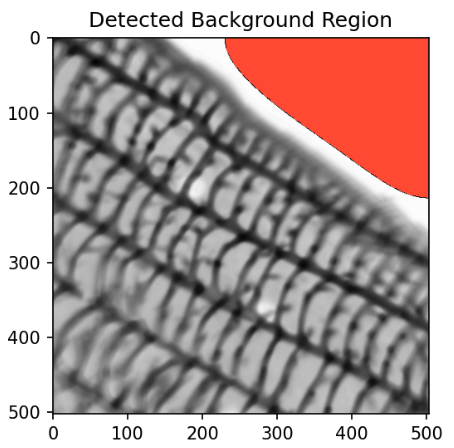

Firstly, figure out how to obtain average spectra of this region. You should obtain something like this:

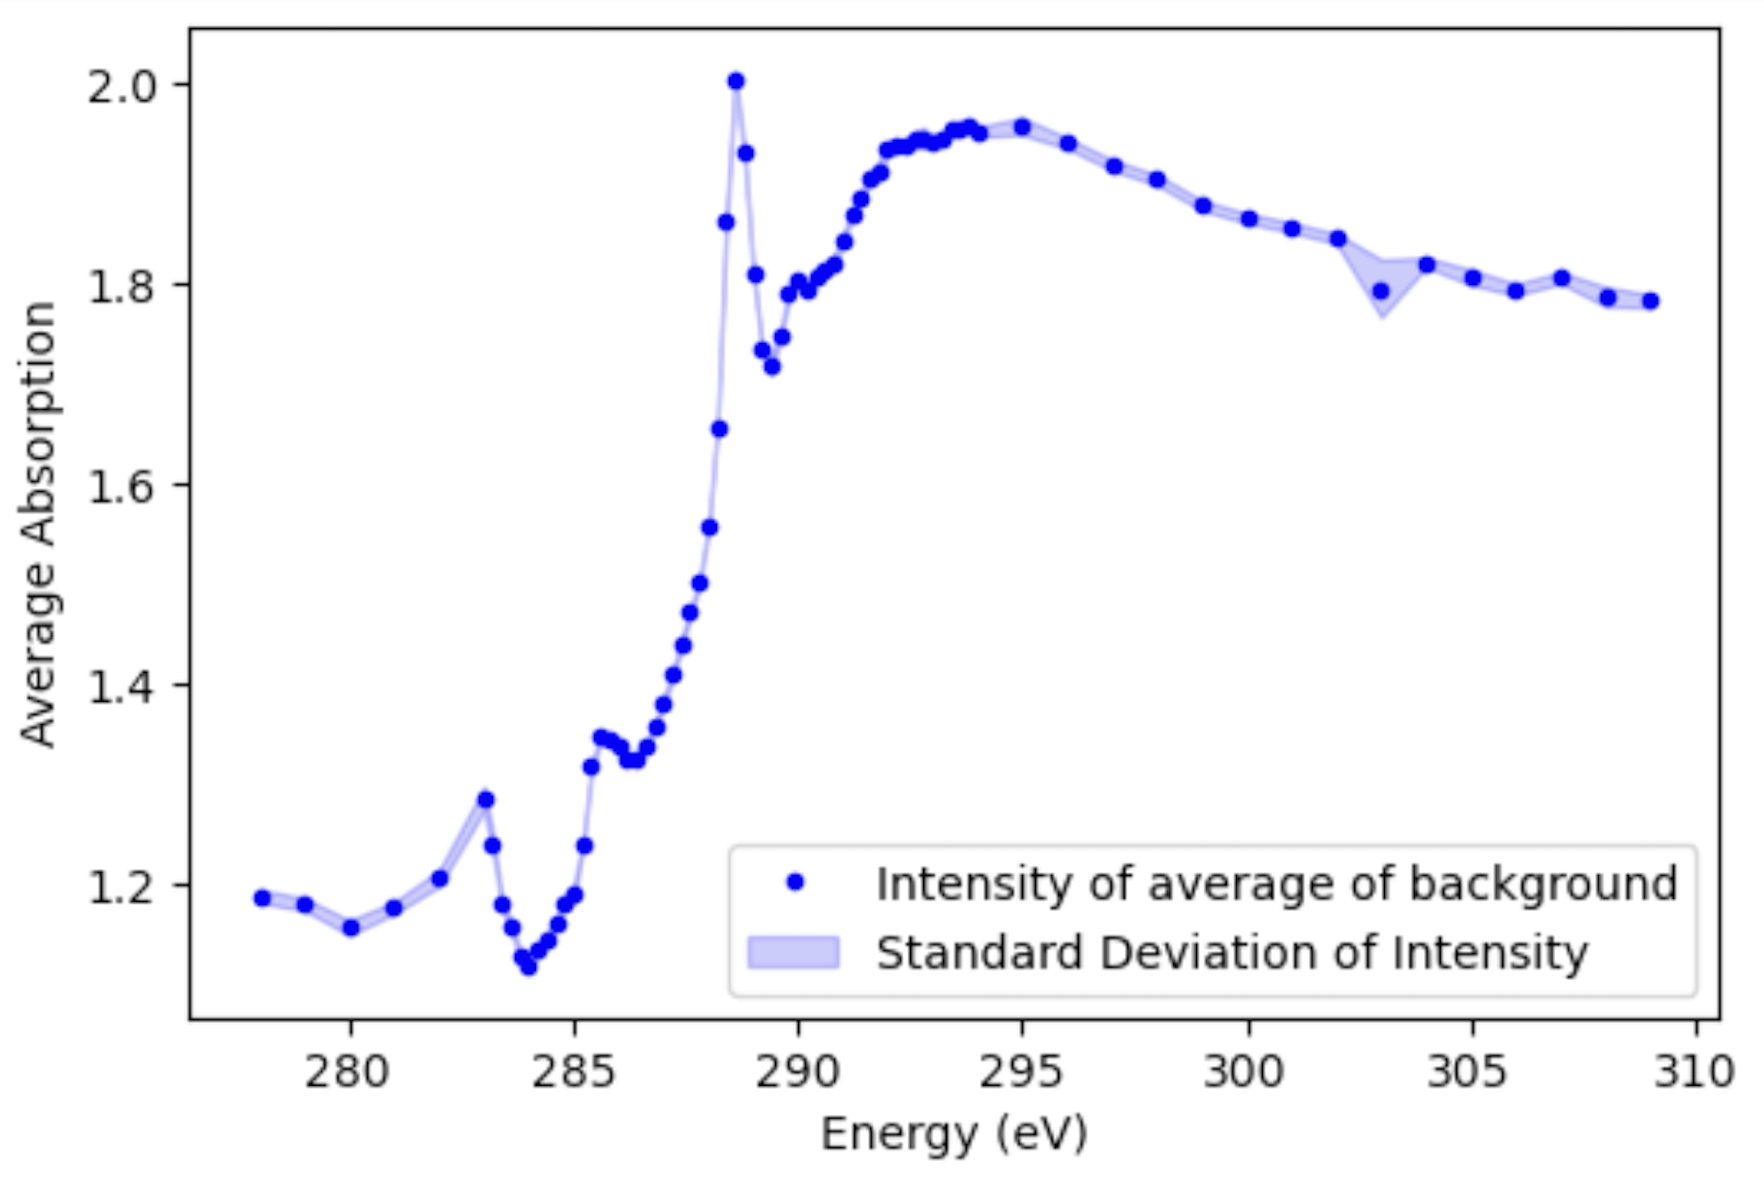

Finally, remove the background spectrum from all spectra (simply divide all spectra by the background spectrum)

[[1.181368   1.1768215  1.1903093  ... 0.8471524  0.9865797  1.0791961 ]
 [1.1942074  1.1877223  1.1996613  ... 0.9021637  1.0269126  1.1101177 ]
 [1.1991212  1.1958373  1.2010058  ... 0.94836324 1.0592189  1.1357751 ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


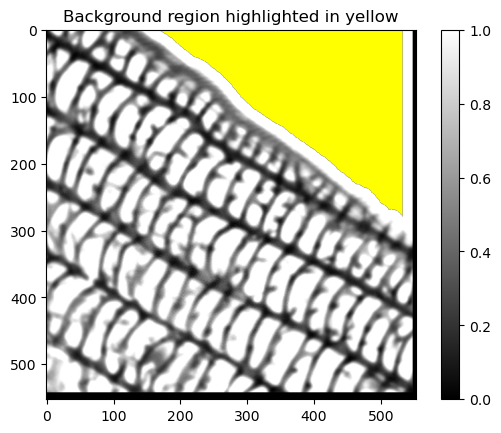

In [16]:
# YOUR TURN!

# choose a energy slice to get background mask
chosen_energy = 290
energy_ind = np.where(energy == chosen_energy)[0][0]
img = amplitude_im[energy_ind]
print(img[100:,100:200])

# Step 1:二值化 binary thresholding
th = 1
bg_mask = img > th

# Step 2: 去除小的白色区域(可能出现在蝴蝶翅膀空洞) remove small objects
bg_mask = remove_small_objects(bg_mask, min_size=10000)

# Step 3: 腐蚀 erosion
bg_mask = erosion(bg_mask, disk(15))

# Step 4: 可视化 visualize
fig, ax = plt.subplots()
im = ax.imshow(img, cmap="gray", vmin = 0, vmax = 1)
ax.imshow(np.ma.masked_where(~bg_mask, bg_mask),
           cmap=plt.cm.colors.ListedColormap(['yellow']), alpha=1.0)
plt.title("Background region highlighted in yellow")
fig.colorbar(im)

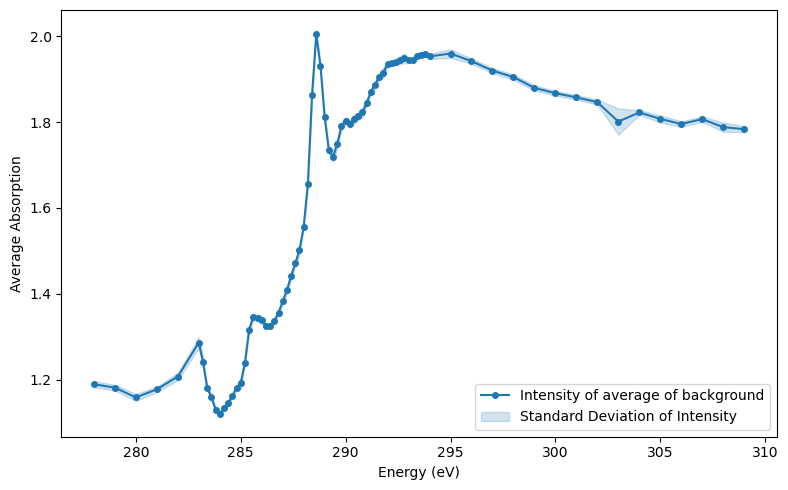

In [17]:
bg_mean = amplitude_im[:,bg_mask].mean(axis=1)
bg_std = amplitude_im[:,bg_mask].std(axis=1, ddof=1)



plt.figure(figsize=(8,5))
plt.plot(energy, bg_mean, '-o', ms=4, color='tab:blue',
         label='Intensity of average of background')
plt.fill_between(energy, bg_mean - bg_std, bg_mean + bg_std,
                 color='tab:blue', alpha=0.2,
                 label='Standard Deviation of Intensity')

plt.xlabel('Energy (eV)')
plt.ylabel('Average Absorption')
plt.legend(loc='lower right')
plt.tight_layout()


In [18]:
# normalize the spectra(remove the background)
print(bg_mean.shape)

eps = 1e-1
absorption = -2 * np.log((abs(amplitude_im) + eps) / (abs(bg_mean) + eps)[:, None, None])
#RuntimeWarning: divide by zero encountered in log
#means some pixels' amplitude is zero

print(absorption.shape)
print("min absorption:", np.min(absorption))
print("max absorption:", np.max(absorption))

(76,)
(76, 553, 553)
min absorption: -0.46595913
max absorption: 6.0932465


--------------
## TASK 3: De-noising Signals

Checking the spectra at each pixel position, we can still observe fluctuations we shouldn't expect. This suggests the data is still somewhat noisy. We now need to denoise the spectra! You should obtain a result similar to the one seen below. You may explore various de-noising methods and determine if a specific method works best.

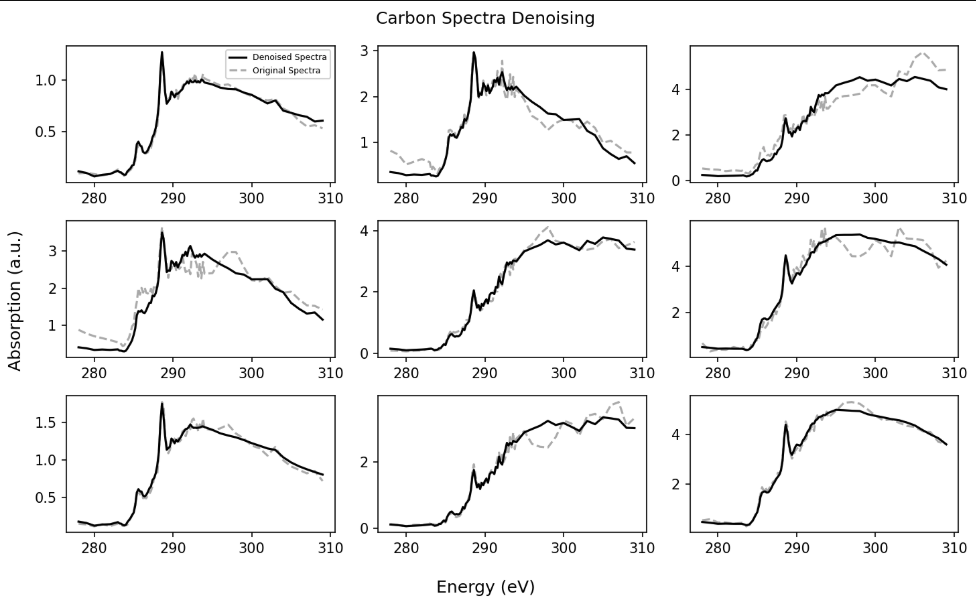

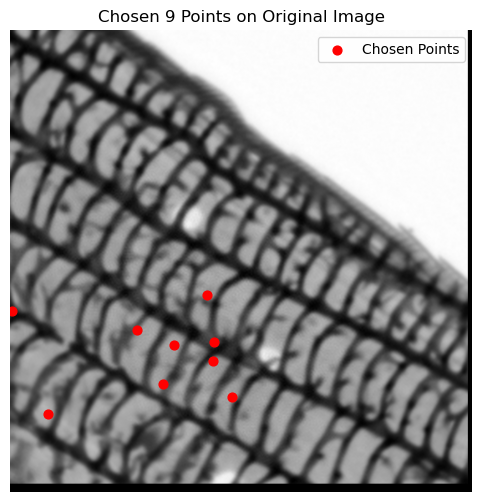

In [19]:
# random choose 9 points to plot the spectra
y_min, y_max = 300, 500
x_min, x_max =0, 300

num_points = 9
ys = np.random.randint(y_min, y_max, size=num_points)
xs = np.random.randint(x_min, x_max, size=num_points)

chosen_points = list(zip(xs, ys))

# 显示原始灰度图 (比如选 290 eV 这一层来展示)
energy_ind = np.where(energy == 290)[0][0]
img = amplitude_im[energy_ind]

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.scatter([x for x, y in chosen_points],
            [y for x, y in chosen_points],
            c="red", s=40, marker="o", label="Chosen Points")

plt.title("Chosen 9 Points on Original Image")
plt.axis("off")
plt.legend()
plt.show()

(305809, 76)


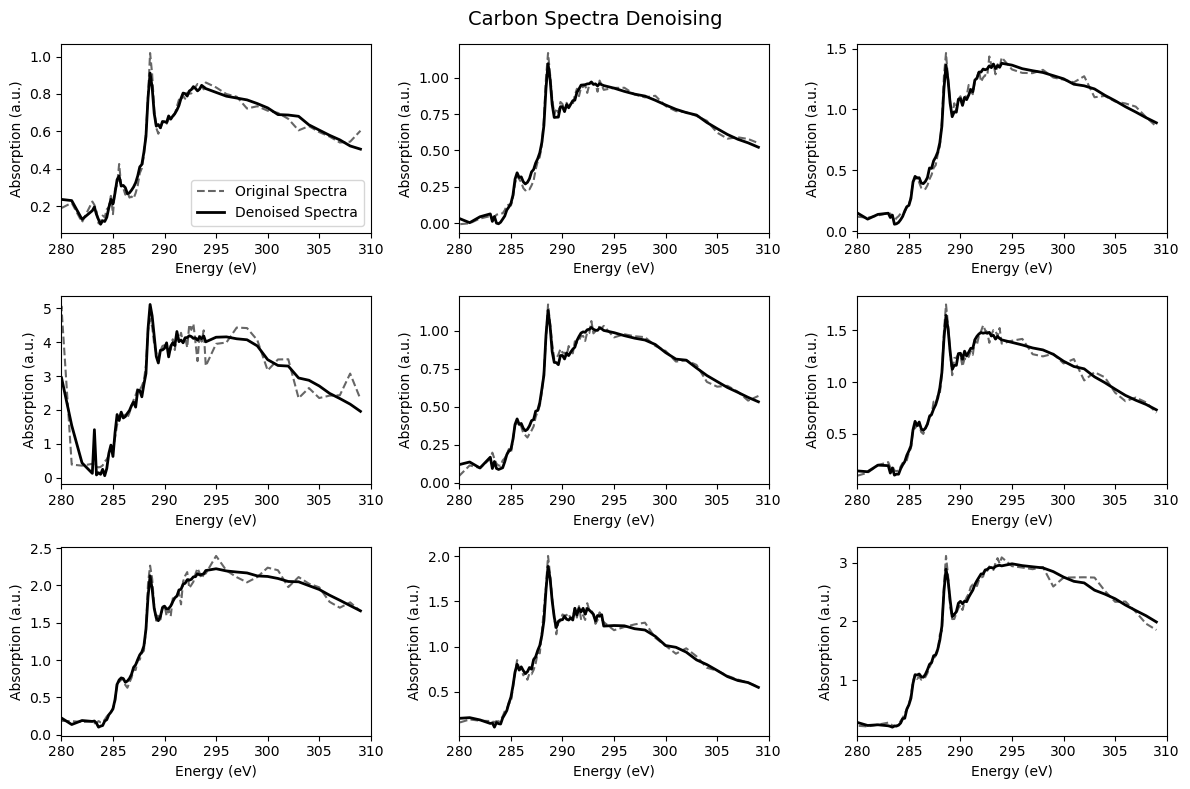

In [20]:
# YOUR TURN!
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


E, H, W = absorption.shape
X = absorption.transpose(1, 2, 0).reshape(-1, E)  # (H*W, E)
print(X.shape)

# normalize the data
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
#amplitude_im_normalized_scaled = X_scaled.reshape(H, W, E).transpose(2, 0, 1)
#print(amplitude_im_normalized_scaled.shape)

# keep n principal components
n = 10
pca = PCA(n_components = n)
X_denoised = pca.inverse_transform(pca.fit_transform(X))

absorption_denoised = X_denoised.reshape(H, W, E).transpose(2, 0, 1)
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.ravel()

for i, (x, y) in enumerate(chosen_points):
    orig = absorption[:, y, x]          # 原始光谱
    denoised = absorption_denoised[:, y, x] # 去噪光谱
    
    axes[i].plot(energy, orig, 'k--', alpha=0.6, label="Original Spectra")
    axes[i].plot(energy, denoised, 'k-', linewidth=2, label="Denoised Spectra")
    axes[i].set_xlim([280, 310])
    axes[i].set_xlabel("Energy (eV)")
    axes[i].set_ylabel("Absorption (a.u.)")

axes[0].legend()
plt.suptitle("Carbon Spectra Denoising", fontsize=14)
plt.tight_layout()
plt.show()



正在测试 k = 1 到 76 的重构损失...


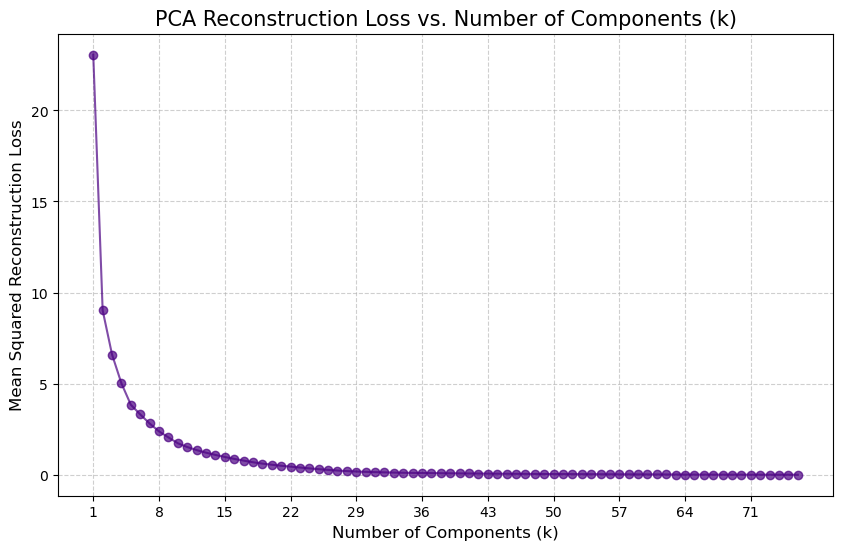


请观察上图的 '肘部' (Elbow)。
在肘部之前，损失下降迅速，代表重要信号。
在肘部之后，损失下降缓慢，代表噪声或冗余信息。
肘部对应的 k 值即为建议的主成分数量。


In [21]:
X_data_for_pca = X

D = X_data_for_pca.shape[1] # 数据的原始特征维度
reconstruction_losses = []
k_values = range(1, D + 1) # 从 1 到 D 的所有 k 值

print(f"正在测试 k = 1 到 {D} 的重构损失...")

for k in k_values:
    # 1. 初始化并拟合 PCA 模型
    pca = PCA(n_components=k)
    pca.fit(X_data_for_pca)
    
    # 2. 降维 (投影)
    Z = pca.transform(X_data_for_pca)
    
    # 3. 重构数据
    # inverse_transform() 实现了 X_hat = Z @ W.T + mean
    # 由于数据已标准化（均值已在 StandardScaler 中处理），此操作是有效的重构
    X_reconstructed = pca.inverse_transform(Z)
    
    # 4. 计算重构损失 (均方误差, MSE)
    # loss = mean(||X_scaled - X_reconstructed||^2)
    # 使用 Frobenius 范数的平方除以样本数
    loss = np.mean(np.sum((X_data_for_pca - X_reconstructed)**2, axis=1))
    
    reconstruction_losses.append(loss)

# --- 可视化重构损失 ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, reconstruction_losses, marker='o', linestyle='-', color='indigo', alpha=0.7)
plt.title('PCA Reconstruction Loss vs. Number of Components (k)', fontsize=15)
plt.xlabel('Number of Components (k)', fontsize=12)
plt.ylabel('Mean Squared Reconstruction Loss', fontsize=12)
plt.xticks(np.arange(1, D + 1, step=max(1, D // 10))) # 调整 x 轴刻度，避免拥挤
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 提示 ---
print("\n请观察上图的 '肘部' (Elbow)。")
print("在肘部之前，损失下降迅速，代表重要信号。")
print("在肘部之后，损失下降缓慢，代表噪声或冗余信息。")
print("肘部对应的 k 值即为建议的主成分数量。")

In [22]:
from sklearn.manifold import TSNE

# n_neighbors_list = [5,10,15,20,25,30]
n_neighbors_list = [50,60,70,80,90,100]
design_matrix = X_denoised
global_rand_seed =42
butt_umap_list = []
# for i in range(6):
#     temp_umap = UMAP(n_neighbors=n_neighbors_list[i], n_components=2, random_state=global_rand_seed)
#     temp_butt_umap = temp_umap.fit_transform(design_matrix)
#     butt_umap_list.append(temp_butt_umap)
for i in range(6):
    temp_umap = TSNE(perplexity=n_neighbors_list[i], random_state=global_rand_seed)
    temp_butt_umap = temp_umap.fit_transform(design_matrix)
    butt_umap_list.append(temp_butt_umap)
butt_umap_list = np.asarray(butt_umap_list)
print(butt_umap_list.shape)

(6, 305809, 2)


In [66]:
std_density = design_matrix.sum(axis = 1)

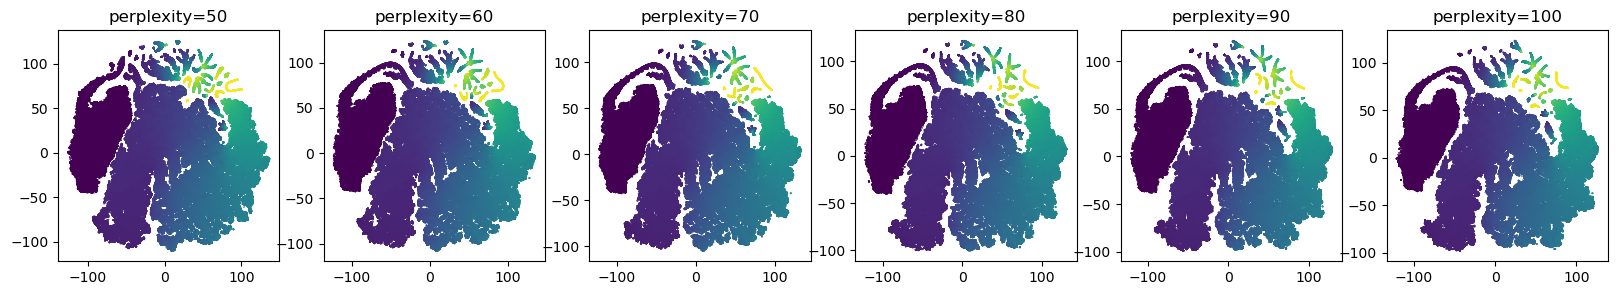

In [67]:
fig, axes = plt.subplots(1,6,figsize=(20,3))
for i in range(6):
    axes[i].scatter(butt_umap_list[i,:,0], butt_umap_list[i,:,1],s=0.1, c = std_density, cmap = 'viridis')
    axes[i].set_title(f'perplexity={n_neighbors_list[i]}')

Text(0.5, 1.0, 'K-Means clustering on TSNE embedding')

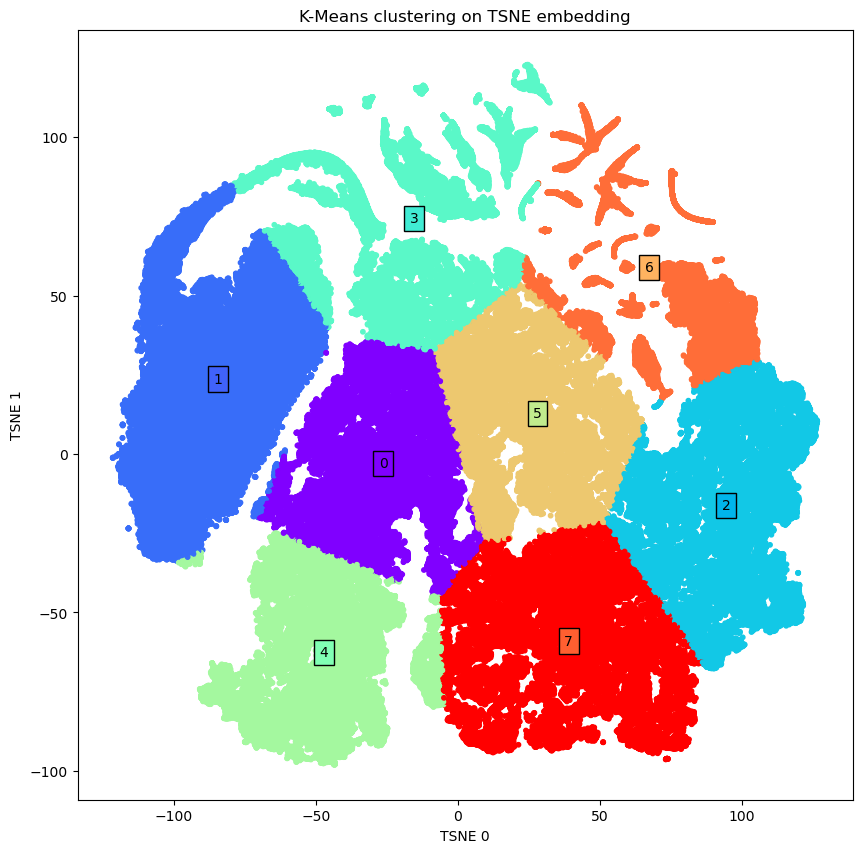

In [59]:
from sklearn.cluster import KMeans
import hdbscan
num_clusters = 8
butt_umap = butt_umap_list[5]

kmeans = KMeans(random_state=global_rand_seed, n_clusters=num_clusters)
butt_kmeans = kmeans.fit_predict(butt_umap)
# butt_kmeans = hdbscan.HDBSCAN().fit_predict(design_matrix)

plt.figure(figsize=(10,10))
plt.scatter(butt_umap[:,0],butt_umap[:,1], c=butt_kmeans, s=10, cmap = plt.cm.rainbow)
_ = [plt.annotate(f'{i}',
                  butt_umap[butt_kmeans == i].mean(axis=0),
                  fontsize = 10,
                  color = 'black',
                  bbox = dict(facecolor = plt.cm.rainbow(i/num_clusters))                        
                 )
     for i in range(num_clusters)]
plt.xlabel("TSNE 0")
plt.ylabel("TSNE 1")
plt.title('K-Means clustering on TSNE embedding')

In [49]:
# Optional: you may use the following helpers to overlay binary mask on images

from matplotlib.colors import ListedColormap
# Transparent for 0, fully opaque red for 1
MASK_CMAP = ListedColormap([[0, 0, 0, 0],
                            [1, 0, 0, 1]])  # RGBA

def mask_rgba(mask, color=(1.0, 0.0, 0.0)):
    """Return an RGBA image that is transparent where mask==0 and colored with alpha=1 where mask==1.
    mask: 2D bool/0-1 array
    color: tuple in [0,1], e.g. (1,0,0) for red
    """
    mask = (mask > 0)
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=float)
    rgba[mask, :3] = color
    rgba[mask, 3] = 1.0
    return rgba

In [50]:
print(design_matrix.shape)

(305809, 76)


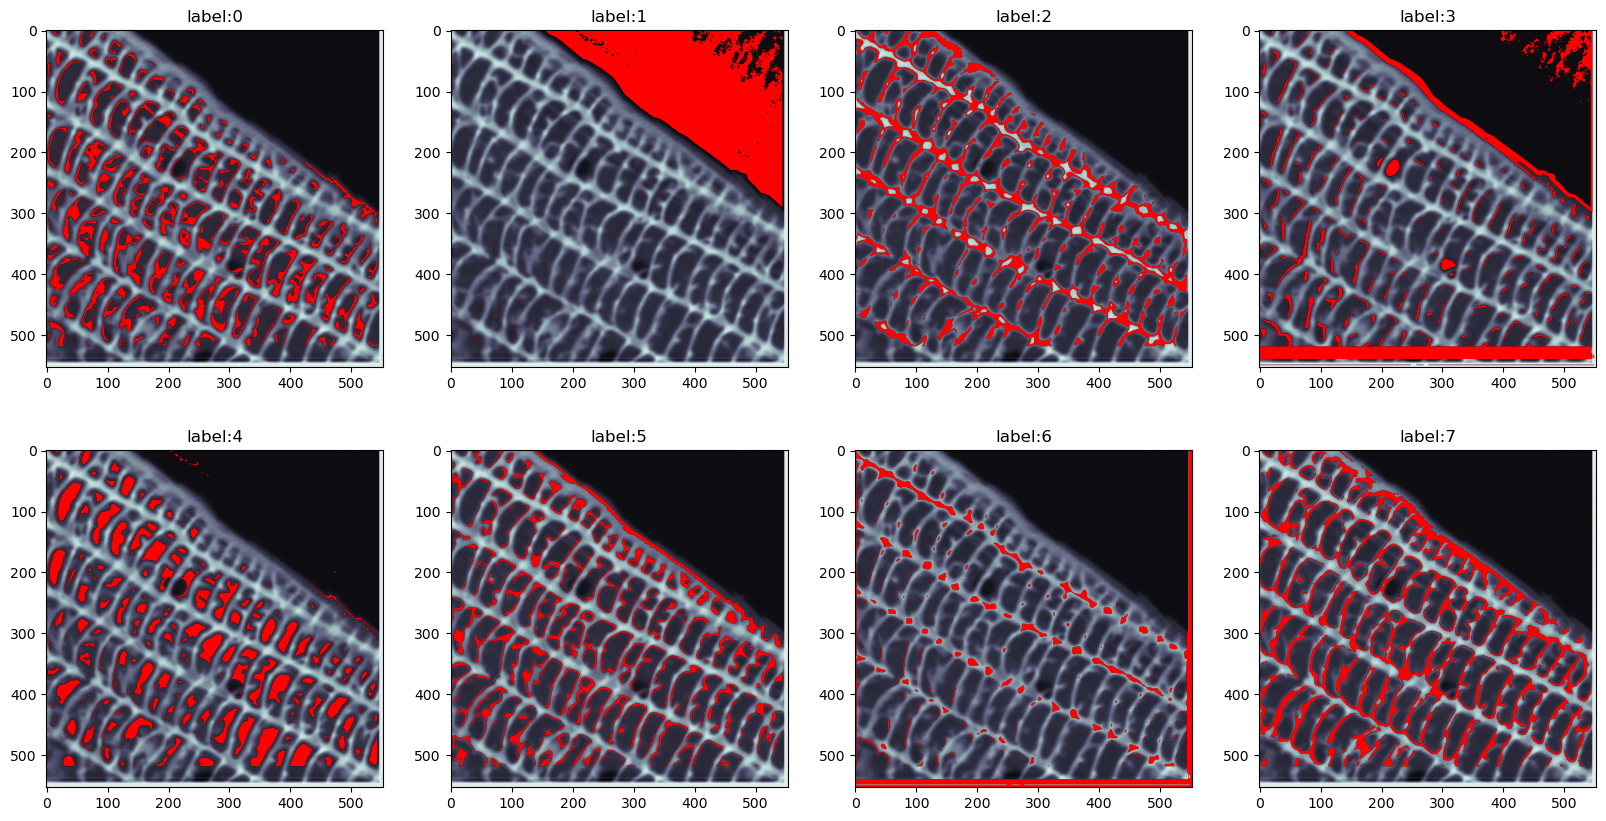

In [58]:
fig,axes = plt.subplots(2,4,figsize=(20,10))
for label,ax in enumerate(axes.ravel()):
        mask = (butt_kmeans == label).reshape(553,553)
        ax.imshow(design_matrix[:,50].reshape(553,553), cmap='bone')
        ax.imshow(mask_rgba(mask))
        ax.set_title(f'label:{label}')
plt.show()

In [60]:
sublist_labels = [[6],
                  [7],
                  [2],
                  [0,4,3,5]]
sublist_types = ["trabeculae", "cross-ribs", "ridges", "lower lamina"]

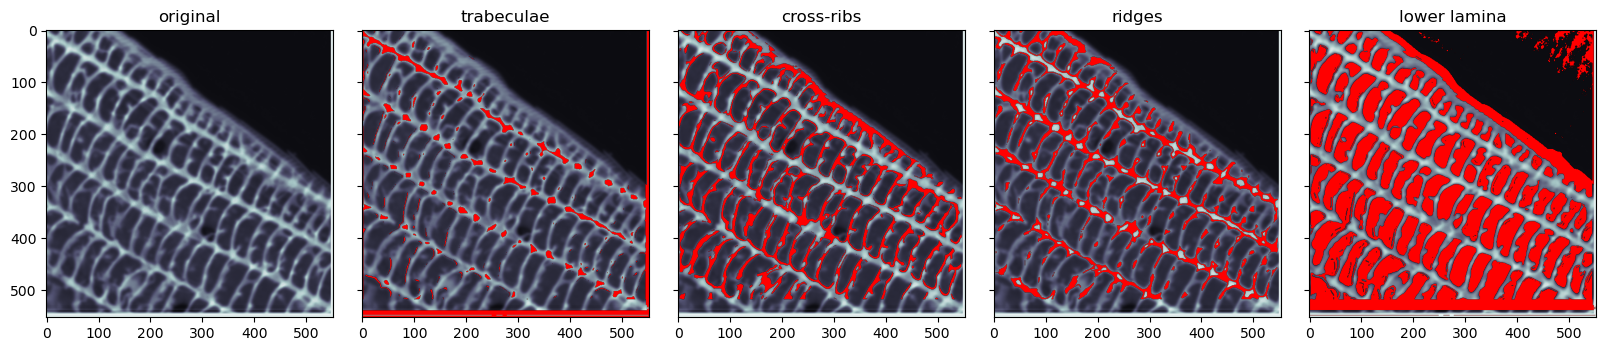

In [64]:
fig, axes = plt.subplots(1,5, figsize=(20,5), sharex=True, sharey=True)
axes[0].imshow(design_matrix[:,50].reshape(553,553), cmap='bone')
axes[0].set_title('original')
for i,l,t in zip(range(4),sublist_labels, sublist_types):
    axes[i+1].imshow(design_matrix[:,50].reshape(553,553), cmap='bone')
    mask = np.isin(butt_kmeans,l).reshape(553,553)
    axes[i+1].imshow(mask_rgba(mask))
    axes[i+1].set_title(f"{t}")
plt.subplots_adjust(wspace=0.1)
plt.show()

--------------
## TASK 4: Pre-edge Removal

We're almost done treating the data! At this point, we still notice a signal before the carbon edge (known as a pre-edge signal), and now need to remove this signal. Remove the contributions from the pre-edge in a similar method as shown below:

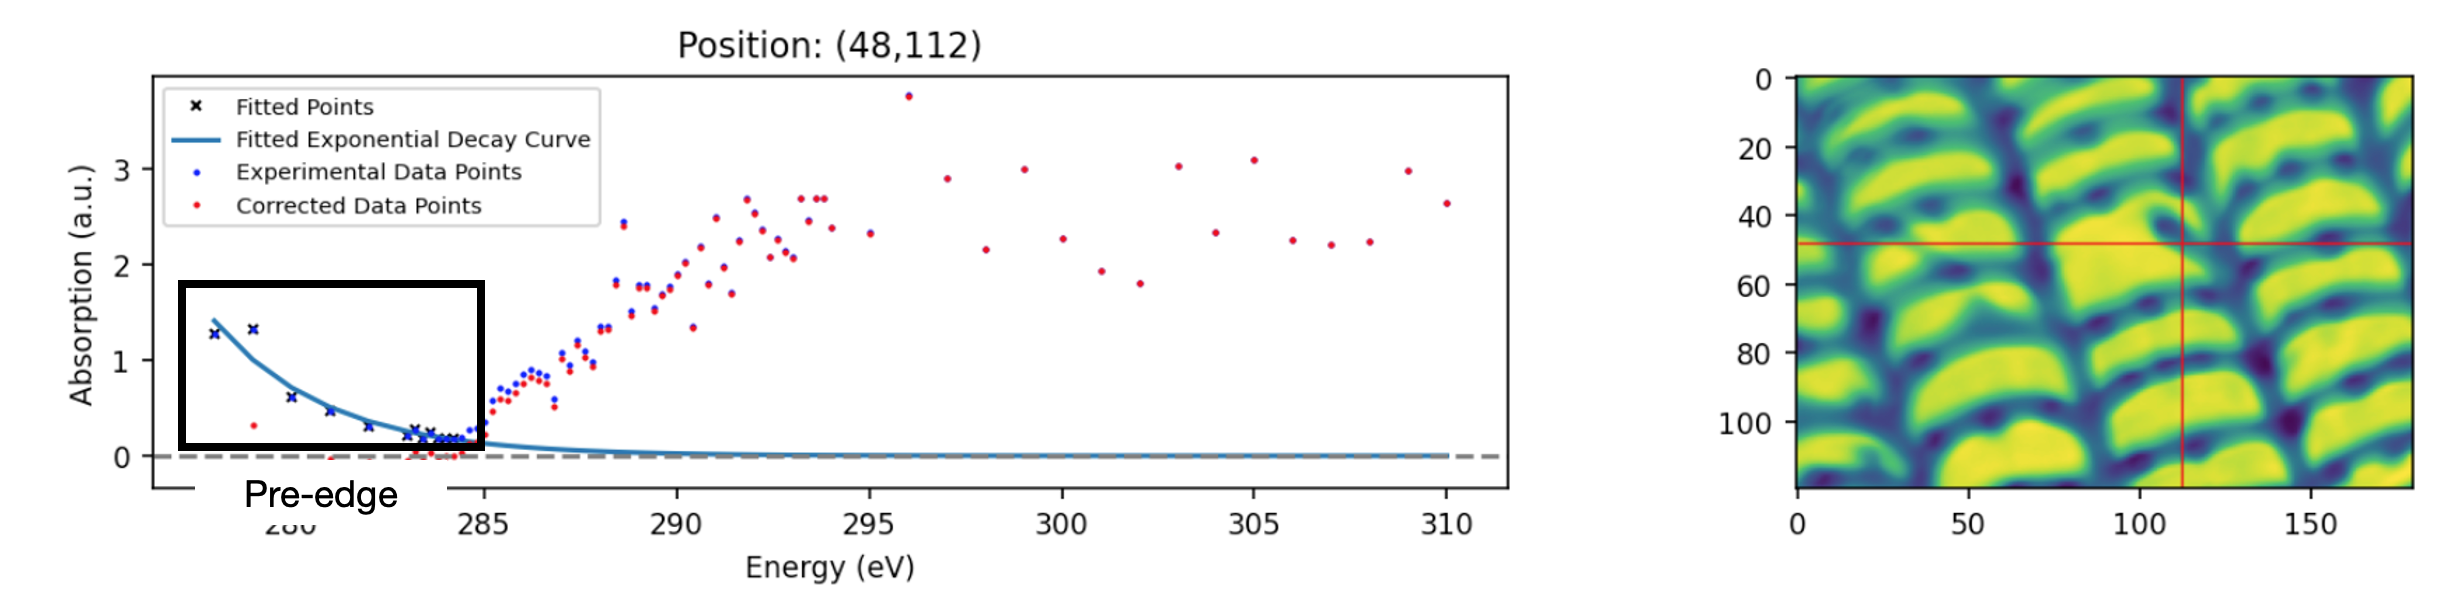

After performing pre-edge removal correctly, you should see the average of all spectra looking like this

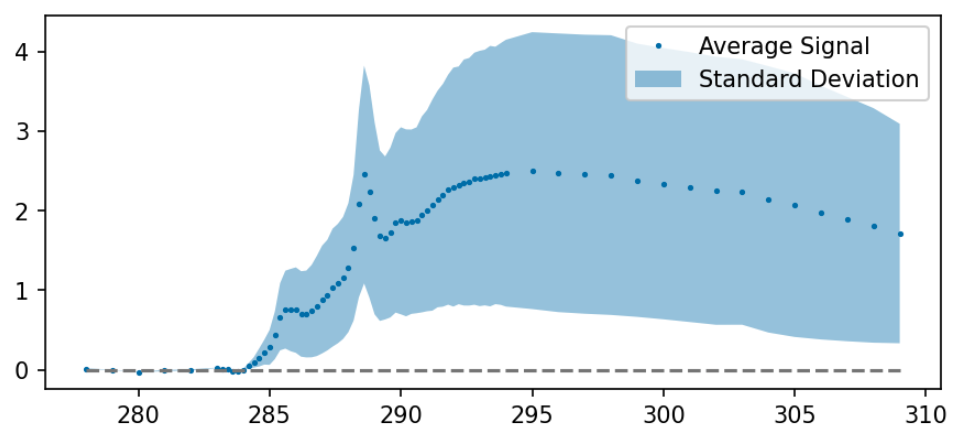

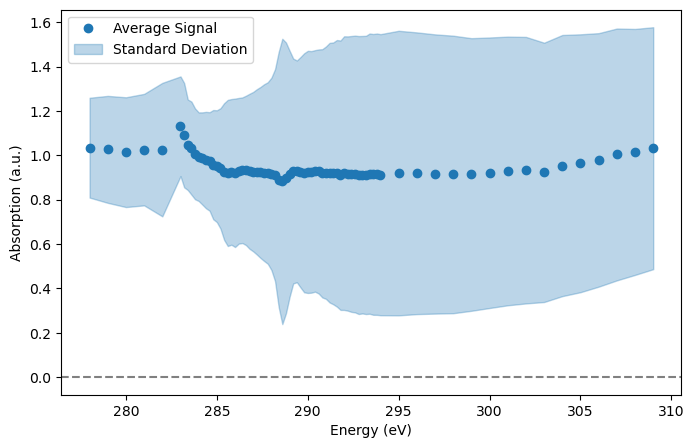

In [18]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 指数基线函数
def exp_baseline(E, A, k, c):
    E0 = E.min()
    return A * np.exp(-k * (E - E0)) + c

E, H, W = amplitude_im.shape
cube = amplitude_im.copy()

# Pre-edge 区间（比如 <= 283.5 eV）
E_EDGE = 284.0
pre_mask = energy <= (E_EDGE - 0.5)
e_pre = energy[pre_mask]

# 输出校正后的 cube
cube_corr = np.zeros_like(cube)

# 遍历每个像素
for y in range(H):
    for x in range(W):
        spectrum = cube[:, y, x]
        y_pre = spectrum[pre_mask]

        # 初始猜测
        p0 = [y_pre.max(), 0.1, np.median(y_pre)]
        bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])

        popt, _ = curve_fit(exp_baseline, e_pre, y_pre, p0=p0, bounds=bounds, maxfev=2000)
        aseline = exp_baseline(energy, *popt)
        cube_corr[:, y, x] = spectrum - baseline

# 保证非负（可选）
cube_corr = np.clip(cube_corr, 0, None)

# 计算平均谱 + 标准差
mean_corr = cube_corr.mean(axis=(1,2))
std_corr  = cube_corr.std(axis=(1,2))

# 可视化平均谱
plt.figure(figsize=(8,5))
plt.plot(energy, mean_corr, 'o', color='tab:blue', label="Average Signal")
plt.fill_between(energy, mean_corr-std_corr, mean_corr+std_corr,
                 color='tab:blue', alpha=0.3, label="Standard Deviation")
plt.axhline(0, color='gray', ls='--')
plt.xlabel("Energy (eV)")
plt.ylabel("Absorption (a.u.)")
plt.legend()
plt.show()

Text(0, 0.5, 'Absorption(a.u.)')

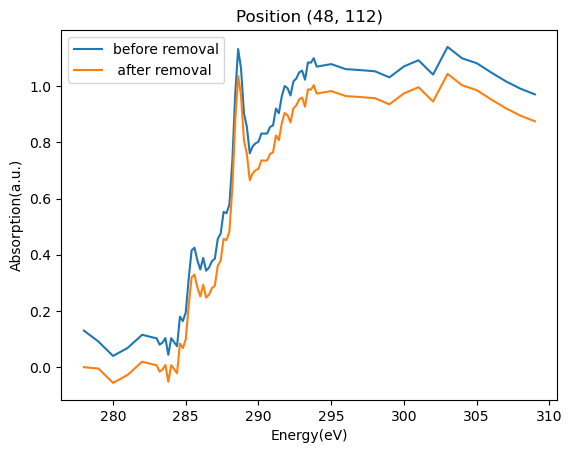

In [14]:
# YOUR TURN!
# pre-edge mask

from scipy.optimize import curve_fit

E, H, W = absorption_denoised.shape

energy_mask = (energy < 285)
e_pre = energy[energy_mask]
E0 = e_pre.min()

# baseline: exponential decay curve
def exp_baseline(E, A, k, c):
    return A * np.exp(-k * (E - E0)) + c

# def fit_block(block_y):
#     """
#     blovk_y:(m, n)
#     m is the number of fitted points
#     n is the number of pixels in one block
#     """
#     m, n = block_y.shape
#     A = np.empty(n); k = np.empty(n); c = np.empty(n)
#     for j in range(n):
#         y = block_y[:,j]
#         # 初值与边界
#         c0 = np.percentile(y, 25)                     # 平台近似
#         A0 = max(y.max() - c0, 1e-6)
#         # 估 k0：用两点近似（保证非负）
#         j1, j2 = 0, m//2
#         num = max(y[j1]-c0, 1e-6); den = max(y[j2]-c0, 1e-6)
#         k0 = max(np.log(num/den) / max(e_pre[j2]-e_pre[j1], 1e-6), 1e-6)

#         p0 = (A0, k0, float(c0))
#         bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf])

#         popt, _ = curve_fit(exp_baseline, e_pre, y, p0=p0, bounds=bounds, maxfev=2000)
#         A[j], k[j], c[j] = popt
    
#     return A, k, c
    
absor_copy = absorption_denoised.copy()
Ypre = absor_copy[energy_mask].reshape(len(e_pre), -1)

# N = Ypre.shape[1]
# blk = 305809                         # 每次拟合多少像素，可按机器调整
# A_all = np.empty(N); k_all = np.empty(N); c_all = np.empty(N)

# for s in range(0, N, blk):
#     e = min(s+blk, N)
#     A, k, c = fit_block(Ypre[:, s:e])
#     A_all[s:e], k_all[s:e], c_all[s:e] = A, k, c

# # 3) 生成整条能量轴上的基线并相减
# baseline = (A_all[None,:] * np.exp(-k_all[None,:] * (energy[:,None] - E0)) + c_all[None,:])  # (E,N)
# baseline = baseline.reshape(E, H, W)

# absor_corrected = absor_copy - baseline


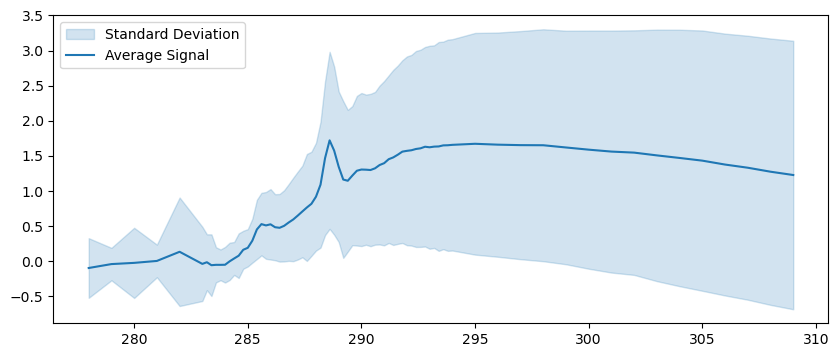

In [16]:
mean_absorption_af_remove = absor_corrected.mean(axis = (1, 2))
#print(mean_absorption_af_remove.shape)
std_absorption_af_remove = absor_corrected.std(axis = (1, 2))

plt.figure(figsize=(10, 4))
plt.fill_between(energy, 
                 mean_absorption_af_remove - std_absorption_af_remove, 
                 mean_absorption_af_remove + std_absorption_af_remove,
                 color='tab:blue', alpha=0.2,
                 label='Standard Deviation',
                 )
plt.plot(energy, mean_absorption_af_remove, color = 'tab:blue', label = 'Average Signal')
plt.legend()